# Mission 13 문제 정의

- 페르소나 : 포르투갈 은행의 마케팅 담당자

- 데이터 : 2008년부터 2010년까지의 은행 마케팅 캠페인 데이터를 포함

- 목표 : 이 데이터를 통해 고객이 정기 예금을 가입할 가능성을 예측하고, 이를 통해 마케팅 캠페인의 효율성을 높이는 것. 마케팅 담당자로서 정기 예금과 관련이 있는 요소들을 파악해보고, 고객의 행동을 이해할 것. 어떤 상황에서 어떤 고객들이 정기 예금을 가입할까?

- 최종 목표 : 가장 정확한 분류 모델을 개발하여 고객이 정기 예금을 가입할지 여부를 예측하고, 그 모델을 통해 도출한 인사이트를 바탕으로 비즈니스 전략을 제시하는 것

- 사용 데이터셋: bank-additional-full.csv

# 분석 환경 설정

In [1]:
# 개발환경 세팅하기
# ▶ 한글 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name() # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 132 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 경로 지정
import os
path = "/content/drive/MyDrive/[2025] CodeIt/[Sprint]mission/mission13/data"
os.chdir(path)

In [5]:
ls

bank-additional-full.csv  bank-additional-names.txt


# EDA

In [6]:
# 데이터 크기 확인
bank = pd.read_csv('bank-additional-full.csv')
print(f"Bank Data Shape: {bank.shape}")

Bank Data Shape: (41188, 1)


In [7]:
bank.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


In [8]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                        --------------  ----- 
 0   age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"  41188 non-null  object
dtypes: object(1)
memory usage: 321.9+ KB


In [9]:
# 테이블 컬럼 분리
bank = pd.read_csv('bank-additional-full.csv', sep=';')

print("Shape:", bank.shape)
print(bank.head())

Shape: (41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  eur

In [10]:
# 컬럼 그룹 정의
고객정보     = ['age', 'job', 'marital', 'education',
               'default', 'housing', 'loan']

캠페인정보   = ['contact', 'month', 'day_of_week', 'duration',
               'campaign', 'pdays', 'previous', 'poutcome']

경제지표     = ['emp.var.rate', 'cons.price.idx',
               'cons.conf.idx', 'euribor3m', 'nr.employed']

타겟         = ['y']

In [11]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [12]:
# 수치형 / 범주형 자동 분류
수치형_컬럼  = bank.select_dtypes(include='number').columns.tolist()
범주형_컬럼  = bank.select_dtypes(include='object').columns.tolist()

In [13]:
print(f"고객 정보    ({len(고객정보)}개)  : {고객정보}")
print(f"캠페인 정보  ({len(캠페인정보)}개)  : {캠페인정보}")
print(f"경제 지표    ({len(경제지표)}개)  : {경제지표}")
print(f"타겟 변수    ({len(타겟)}개)  : {타겟}")
print()
print(f"수치형 컬럼  ({len(수치형_컬럼)}개)  : {수치형_컬럼}")
print(f"범주형 컬럼  ({len(범주형_컬럼)}개)  : {범주형_컬럼}")

고객 정보    (7개)  : ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
캠페인 정보  (8개)  : ['contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
경제 지표    (5개)  : ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
타겟 변수    (1개)  : ['y']

수치형 컬럼  (10개)  : ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
범주형 컬럼  (11개)  : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [14]:
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [15]:
# 타겟 분포 확인
print(bank['y'].value_counts())
print(bank['y'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.7%
yes    11.3%
Name: proportion, dtype: object


In [16]:
# 범주형 데이터 카테고리 확인
# 표기 오류 검토
for col in ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']:
    print(f"\n[{col}]", bank[col].unique())


[job] ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

[marital] ['married' 'single' 'divorced' 'unknown']

[education] ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

[contact] ['telephone' 'cellular']

[month] ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

[day_of_week] ['mon' 'tue' 'wed' 'thu' 'fri']

[poutcome] ['nonexistent' 'failure' 'success']


# 데이터 전처리

## 중복값 확인 및 처리

In [17]:
# 중복값 확인
print(bank.duplicated().sum())

12


In [18]:
# 중복 데이터 내용 확인
duplicates = bank[bank.duplicated(keep=False)]
print(f"중복 데이터 건수: {len(duplicates)}")
display(duplicates.sort_values(by=list(bank.columns)).head(10))

중복 데이터 건수: 24


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


In [19]:
# 중복 데이터 제거
bank = bank.drop_duplicates()
print(f"제거 후 데이터 크기: {bank.shape}")

제거 후 데이터 크기: (41176, 21)


In [20]:
# 전체 중복 건수 재확인
print(f"현재 중복 데이터 건수: {bank.duplicated().sum()}")

현재 중복 데이터 건수: 0


## 결측치 확인 및 처리

In [21]:
bank.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [22]:
# unknown 결측치 비율 확인
unknown_counts = (bank == 'unknown').sum()
unknown_ratio = (unknown_counts / len(bank)) * 100

# 결측치가 있는 컬럼만 내림차순으로 출력
missing_info = pd.DataFrame({'count': unknown_counts, 'ratio(%)': unknown_ratio})
print(missing_info[missing_info['count'] > 0].sort_values(by='ratio(%)', ascending=False))

           count   ratio(%)
default     8596  20.876239
education   1730   4.201477
housing      990   2.404313
loan         990   2.404313
job          330   0.801438
marital       80   0.194288


In [23]:
# 0.8, 0.2%의 jpb, marital의 결측치 삭제하기
bank = bank.dropna(subset=['job', 'marital'])

In [24]:
# 2.4%의 housing, loan의 결측치는 최빈값으로 대체하기
bank['housing'].fillna(bank['housing'].mode()[0], inplace=True)
bank['loan'].fillna(bank['loan'].mode()[0], inplace=True)

In [25]:
# education의 카테고리 범주 확인하기
print(bank['education'].unique())

['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']


In [26]:
# default의 카테고리 범주 확인하기
# default = 채무불이행
print(bank['default'].unique())

['no' 'unknown' 'yes']


In [27]:
# default의 각 카테고리별 비율 확인하기
print(bank['default'].value_counts())
print(bank['default'].value_counts(normalize=True))

default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64
default
no         0.791165
unknown    0.208762
yes        0.000073
Name: proportion, dtype: float64


In [28]:
# 'y' 컬럼을 숫자로 변환하여 'default'별 가입 비율(mean) 확인
bank['target_n'] = bank['y'].apply(lambda x: 1 if x == 'yes' else 0)
bank.groupby('default')['target_n'].mean().sort_values(ascending=False)

,target_n
default,
no,0.128803
unknown,0.051536
yes,0.000000


In [29]:
# default가 'yes'인 데이터(3건) 삭제
bank = bank[bank['default'] != 'yes']

# 삭제 후 결과 확인
print(f"삭제 후 데이터 크기: {bank.shape}")
print(bank['default'].value_counts())

삭제 후 데이터 크기: (41173, 22)
default
no         32577
unknown     8596
Name: count, dtype: int64


## 이상치 확인 및 처리

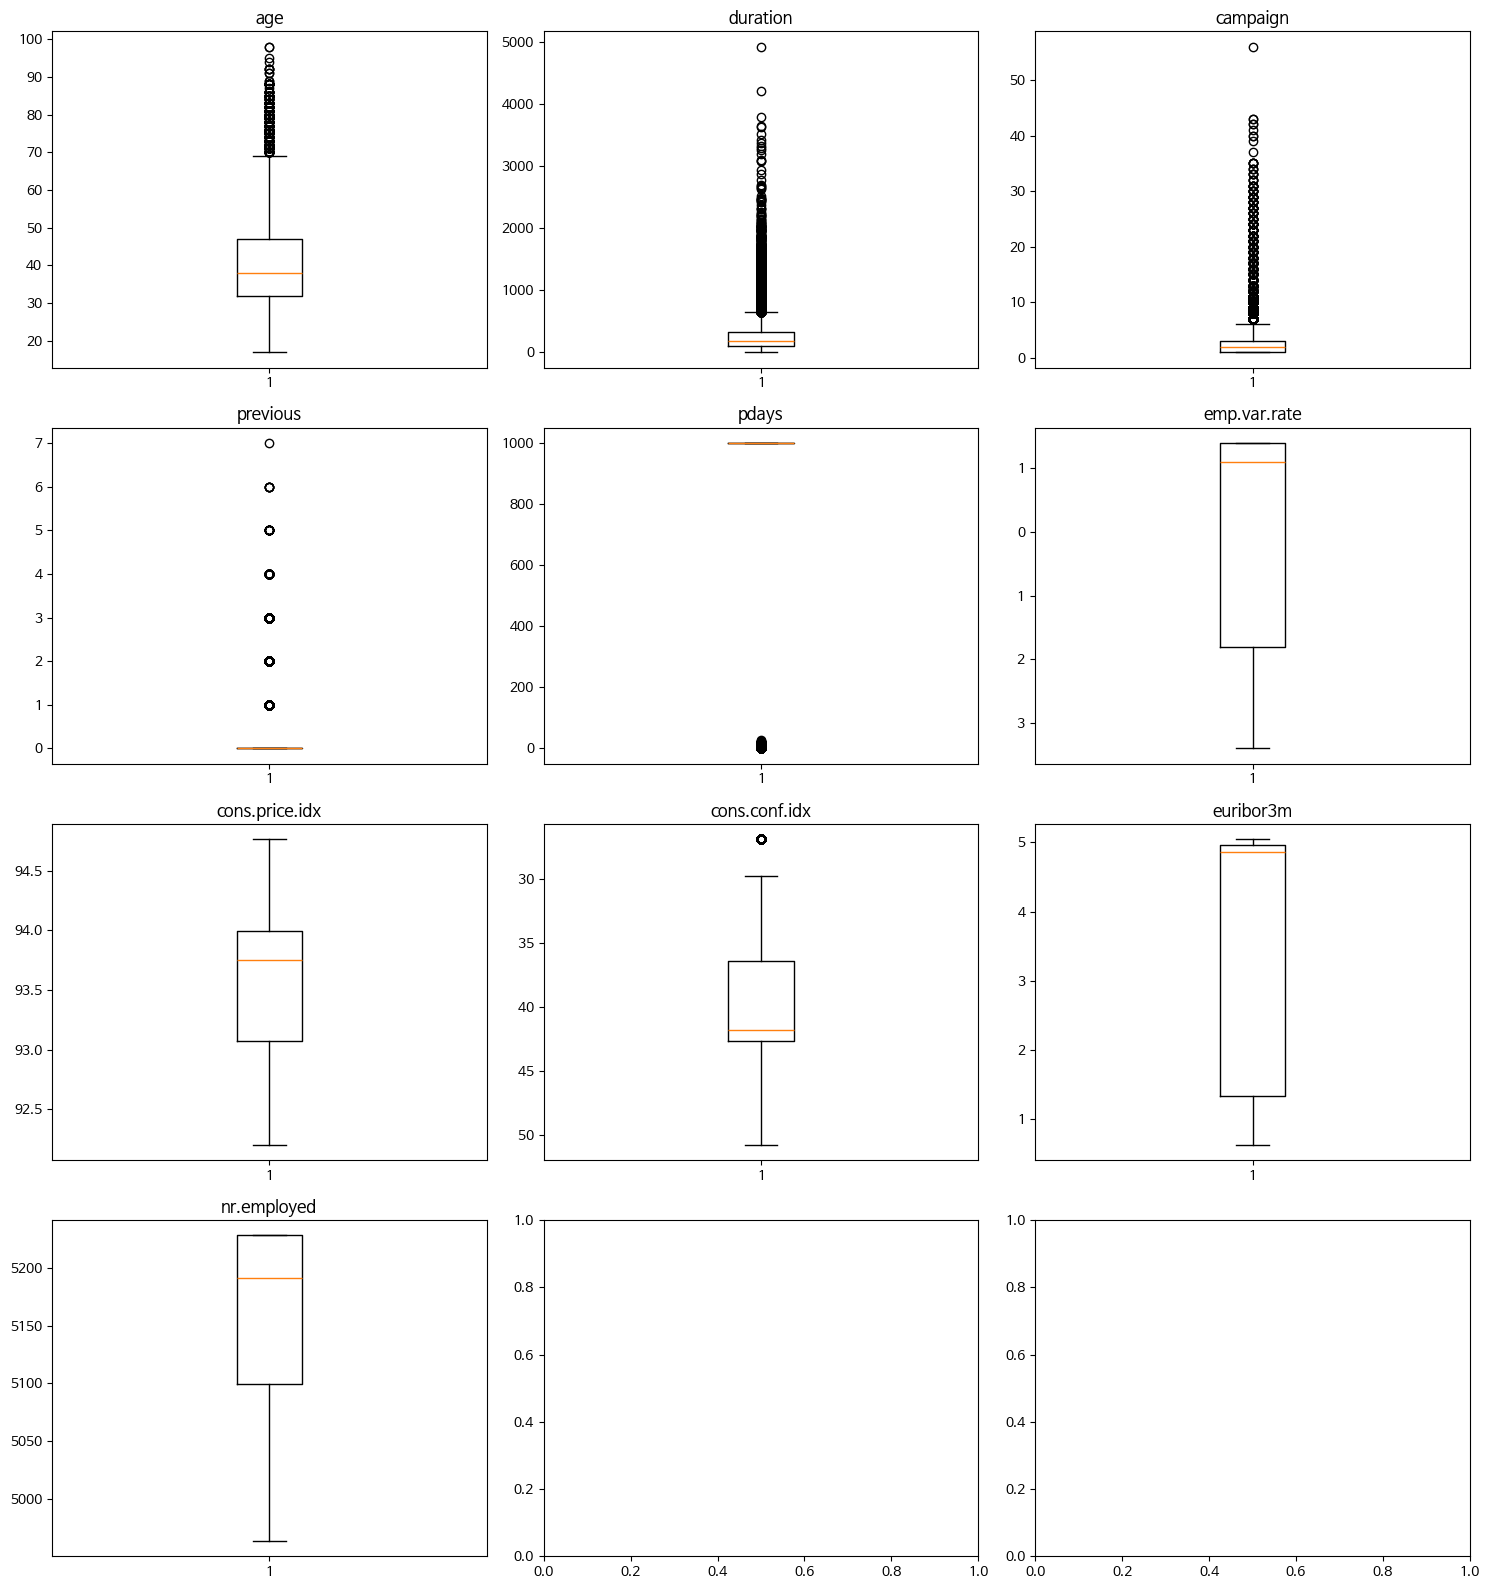

In [30]:
# 이상치 확인
# 수치형 컬럼만
num_cols = ['age', 'duration', 'campaign', 'previous','pdays',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']

# 4행 3열(12칸)
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(bank[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [31]:
# IQR 확인
# age, duration, campaign, previous, pdays
# 경제지표는 이상치 제거 대상 아님
num_cols = ['age', 'duration', 'campaign', 'previous', 'pdays']

# 기술통계 확인
print(bank[num_cols].describe())

# IQR 기반 이상치 범위 계산
for col in num_cols:
    Q1 = bank[col].quantile(0.25)
    Q3 = bank[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = bank[(bank[col] < lower) | (bank[col] > upper)]
    print(f"\n[{col}] 정상 범위: {lower:.1f} ~ {upper:.1f} | 이상치 수: {len(outliers)} ({len(outliers)/len(bank)*100:.1f}%)")


                age      duration      campaign      previous         pdays
count  41173.000000  41173.000000  41173.000000  41173.000000  41173.000000
mean      40.023632    258.327108      2.567969      0.173002    962.462148
std       10.420816    259.311284      2.770396      0.494964    186.943652
min       17.000000      0.000000      1.000000      0.000000      0.000000
25%       32.000000    102.000000      1.000000      0.000000    999.000000
50%       38.000000    180.000000      2.000000      0.000000    999.000000
75%       47.000000    319.000000      3.000000      0.000000    999.000000
max       98.000000   4918.000000     56.000000      7.000000    999.000000

[age] 정상 범위: 9.5 ~ 69.5 | 이상치 수: 468 (1.1%)

[duration] 정상 범위: -223.5 ~ 644.5 | 이상치 수: 2963 (7.2%)

[campaign] 정상 범위: -2.0 ~ 6.0 | 이상치 수: 2406 (5.8%)

[previous] 정상 범위: 0.0 ~ 0.0 | 이상치 수: 5624 (13.7%)

[pdays] 정상 범위: 999.0 ~ 999.0 | 이상치 수: 1515 (3.7%)


In [32]:
#'duration'상세 분석
Q1 = bank['duration'].quantile(0.25)
Q3 = bank['duration'].quantile(0.75)
IQR = Q3 - Q1

# 상한값
upper_bound = Q3 + 1.5 * IQR

# 정상통화시간 그룹 vs. 이상치통화시간 그룹 dataset 나누기
df_normal = bank[bank['duration'] <= upper_bound]
df_outlier = bank[bank['duration'] > upper_bound]

print(f"통화시간 상한값: {upper_bound:.2f}")
print(f"정상 그룹: {len(df_normal)}")
print(f"이상 그룹: {len(df_outlier)}")

통화시간 상한값: 644.50
정상 그룹: 38210
이상 그룹: 2963


In [33]:
# 목표변수 평균값
rate_normal = df_normal['target_n'].mean() * 100
rate_outlier = df_outlier['target_n'].mean() * 100

print(f"정상 그룹 정기예금 가입율: {rate_normal:.2f}%")
print(f"이상 그룹 정기예금 가입율: {rate_outlier:.2f}%")

#
ratio = rate_outlier / rate_normal if rate_normal > 0 else 0
print(f"\n이상 그룹의 정기예금 가입율은 정상 그룹보다 {ratio:.1f}배 높다.")

정상 그룹 정기예금 가입율: 8.15%
이상 그룹 정기예금 가입율: 51.50%

이상 그룹의 정기예금 가입율은 정상 그룹보다 6.3배 높다.


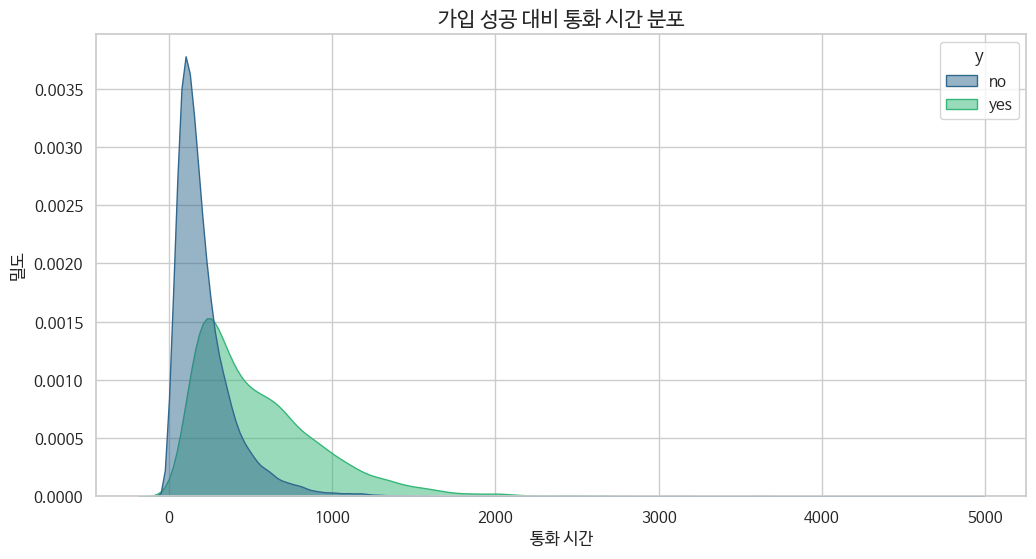

In [34]:
# 시각화하기
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})
plt.figure(figsize=(12, 6))

# KDE plot
sns.kdeplot(data=bank, x='duration', hue='y', fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title('가입 성공 대비 통화 시간 분포', fontsize=15)
plt.xlabel('통화 시간', fontsize=12)
plt.ylabel('밀도', fontsize=12)

plt.show()

In [35]:
#'campaign'상세 분석
Q1 = bank['campaign'].quantile(0.25)
Q3 = bank['campaign'].quantile(0.75)
IQR = Q3 - Q1

# 상한값
upper_bound_campaign = Q3 + 1.5 * IQR

# 정상 그룹 vs. 이상치 그룹 dataset 나누기
df_normal_campaign = bank[bank['campaign'] <= upper_bound_campaign]
df_outlier_campaign = bank[bank['campaign'] > upper_bound_campaign]

print(f"캠페인 상한값: {upper_bound_campaign:.2f}")
print(f"정상 그룹: {len(df_normal_campaign)}")
print(f"이상 그룹: {len(df_outlier_campaign)}")

캠페인 상한값: 6.00
정상 그룹: 38767
이상 그룹: 2406


In [36]:
# 목표변수 평균값
rate_normal_campaign = df_normal_campaign['target_n'].mean() * 100
rate_outlier_campaign = df_outlier_campaign['target_n'].mean() * 100

print(f"정상 그룹 정기예금 가입율: {rate_normal_campaign:.2f}%")
print(f"이상 그룹 정기예금 가입율: {rate_outlier_campaign:.2f}%")

#
ratio_campaign = rate_outlier_campaign / rate_normal_campaign if rate_normal_campaign > 0 else 0
print(f"\n이상 그룹의 정기예금 가입율은 정상 그룹보다 {ratio_campaign:.1f}배 높다.")

정상 그룹 정기예금 가입율: 11.68%
이상 그룹 정기예금 가입율: 4.61%

이상 그룹의 정기예금 가입율은 정상 그룹보다 0.4배 높다.


In [37]:
#'previous'상세 분석
Q1 = bank['previous'].quantile(0.25)
Q3 = bank['previous'].quantile(0.75)
IQR = Q3 - Q1

# 상한값
upper_bound_previous = Q3 + 1.5 * IQR

# 정상 그룹 vs. 이상치 그룹 dataset 나누기
df_normal_previous = bank[bank['previous'] <= upper_bound_previous]
df_outlier_previous = bank[bank['previous'] > upper_bound_previous]

print(f"캠페인 상한값: {upper_bound_previous:.2f}")
print(f"정상 그룹: {len(df_normal_previous)}")
print(f"이상 그룹: {len(df_outlier_previous)}")

캠페인 상한값: 0.00
정상 그룹: 35549
이상 그룹: 5624


In [38]:
# 목표변수 평균값
rate_normal_previous = df_normal_previous['target_n'].mean() * 100
rate_outlier_previous = df_outlier_previous['target_n'].mean() * 100

print(f"정상 그룹 정기예금 가입율: {rate_normal_previous:.2f}%")
print(f"이상 그룹 정기예금 가입율: {rate_outlier_previous:.2f}%")

#
ratio_previous = rate_outlier_previous / rate_normal_previous if rate_normal_previous > 0 else 0
print(f"\n이상 그룹의 정기예금 가입율은 정상 그룹보다 {ratio_previous:.1f}배 높다.")

정상 그룹 정기예금 가입율: 8.83%
이상 그룹 정기예금 가입율: 26.65%

이상 그룹의 정기예금 가입율은 정상 그룹보다 3.0배 높다.


In [39]:
#'pdays'상세 분석
Q1 = bank['pdays'].quantile(0.25)
Q3 = bank['pdays'].quantile(0.75)
IQR = Q3 - Q1

# 상한값
upper_bound_pdays = Q3 + 1.5 * IQR

# 정상 그룹 vs. 이상치 그룹 dataset 나누기
df_normal_pdays = bank[bank['pdays'] <= upper_bound_pdays]
df_outlier_pdays = bank[bank['pdays'] > upper_bound_pdays]

print(f"캠페인 상한값: {upper_bound_pdays:.2f}")
print(f"정상 그룹: {len(df_normal_pdays)}")
print(f"이상 그룹: {len(df_outlier_pdays)}")

캠페인 상한값: 999.00
정상 그룹: 41173
이상 그룹: 0


In [40]:
# pdays에서 999가 대부분이라 999 제외하고 다시 확인
pdays_filtered = bank[bank['pdays'] != 999]['pdays']
pdays_filtered.describe()

,pdays
count,1515.000000
mean,6.014521
std,3.824906
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,27.000000


In [41]:
# pdays 파생변수 생성
# 0 = 이전 캠페인 미접촉, 1 = 접촉 이력 있음
bank['pdays_contacted'] = (bank['pdays'] != 999).astype(int)

In [42]:
# pdays 컬럼 삭제
bank = bank.drop(columns=['pdays'])

## 상관관계 확인

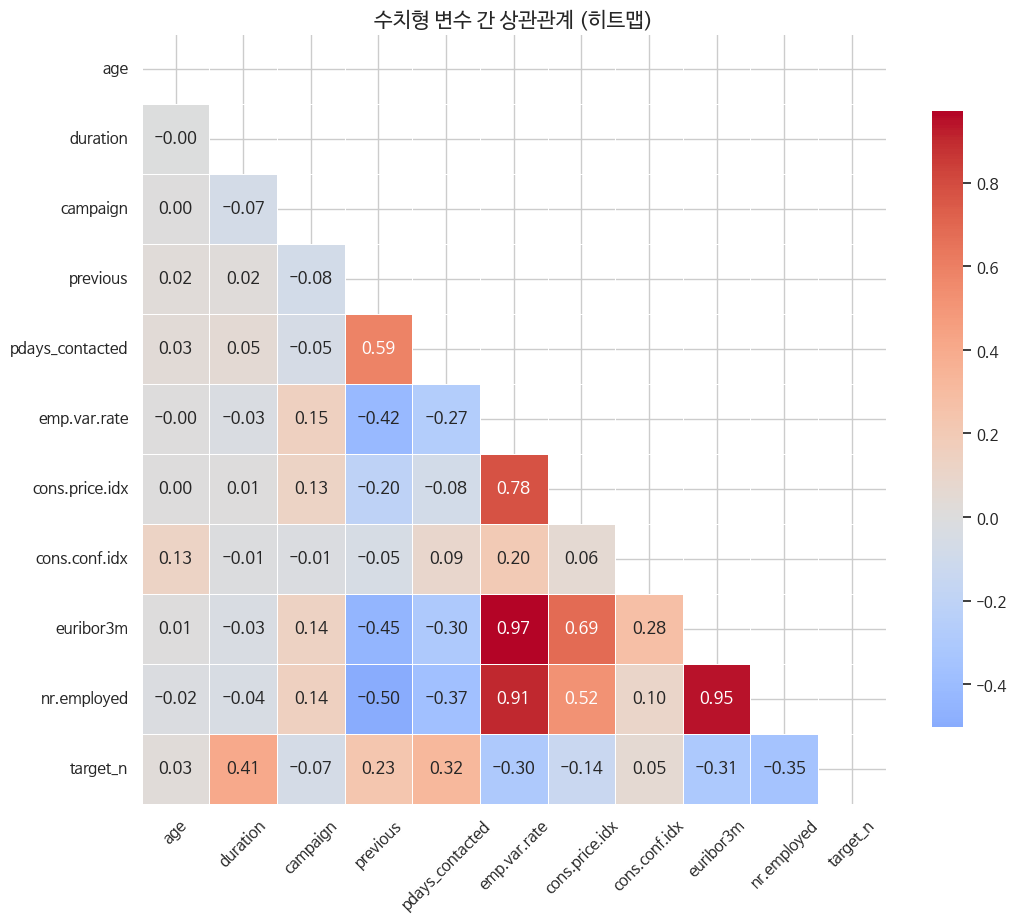

In [43]:
# 수치형 데이터 상관관계 히트맵 가시성 개선
plt.figure(figsize=(12, 10))

# 상관계수 계산
num_cols = ['age', 'duration', 'campaign', 'previous', 'pdays_contacted',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed', 'target_n']
corr = bank[num_cols].corr()

# 중복 정보 제거
mask = np.triu(np.ones_like(corr, dtype=bool))

# 히트맵 그리기
sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={'shrink': .8})

plt.title('수치형 변수 간 상관관계 (히트맵)', fontsize=15)
plt.xticks(rotation=45)
plt.show()

# 데이터 가공

## 원핫인코딩

In [44]:
범주형_컬럼  = bank.select_dtypes(include='object').columns.tolist()
print(f"범주형 컬럼  ({len(범주형_컬럼)}개)  : {범주형_컬럼}")

범주형 컬럼  (11개)  : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [45]:
# 현재 df에 바로 적용하면 자동으로 합쳐짐
bank = pd.get_dummies(bank, columns=['job', 'marital', 'default', 'housing', 'loan',
                                  'contact', 'month', 'day_of_week', 'poutcome'])

print(bank.shape)
print(bank.dtypes)

(41173, 57)
age                       int64
education                object
duration                  int64
campaign                  int64
previous                  int64
emp.var.rate            float64
cons.price.idx          float64
cons.conf.idx           float64
euribor3m               float64
nr.employed             float64
y                        object
target_n                  int64
pdays_contacted           int64
job_admin.                 bool
job_blue-collar            bool
job_entrepreneur           bool
job_housemaid              bool
job_management             bool
job_retired                bool
job_self-employed          bool
job_services               bool
job_student                bool
job_technician             bool
job_unemployed             bool
job_unknown                bool
marital_divorced           bool
marital_married            bool
marital_single             bool
marital_unknown            bool
default_no                 bool
default_unknown            b

In [46]:
# boolean 타입 정수형(0, 1)으로 변환
bool_cols = bank.select_dtypes(include='bool').columns
bank[bool_cols] = bank[bool_cols].astype(int)

print(f"변환된 컬럼 수: {len(bool_cols)}")
bank.info()

변환된 컬럼 수: 44
<class 'pandas.core.frame.DataFrame'>
Index: 41173 entries, 0 to 41187
Data columns (total 57 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   41173 non-null  int64  
 1   education             41173 non-null  object 
 2   duration              41173 non-null  int64  
 3   campaign              41173 non-null  int64  
 4   previous              41173 non-null  int64  
 5   emp.var.rate          41173 non-null  float64
 6   cons.price.idx        41173 non-null  float64
 7   cons.conf.idx         41173 non-null  float64
 8   euribor3m             41173 non-null  float64
 9   nr.employed           41173 non-null  float64
 10  y                     41173 non-null  object 
 11  target_n              41173 non-null  int64  
 12  pdays_contacted       41173 non-null  int64  
 13  job_admin.            41173 non-null  int64  
 14  job_blue-collar       41173 non-null  int64  
 15  job_entrepr

## 라벨 인코딩

In [47]:
education_order = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': -1   # 별도 처리 또는 최빈값으로 대체 가능
}

bank['education_n'] = bank['education'].map(education_order)

In [48]:
print(bank[['education', 'education_n']].value_counts().sort_index())
print(bank['education_n'].isna().sum())  # NaN 없는지 체크

education            education_n
basic.4y              1              4176
basic.6y              2              2291
basic.9y              3              6045
high.school           4              9511
illiterate            0                18
professional.course   5              5238
university.degree     6             12164
unknown              -1              1730
Name: count, dtype: int64
0


In [49]:
# 현재 df에 문자열 컬럼이 남아있는지 확인
print(bank.select_dtypes(include='object').columns.tolist())

['education', 'y']


In [50]:
# 원본 문자열 컬럼 제거 (education 원본, y 문자열 버전)
bank = bank.drop(columns=['education', 'y'])

print(bank.select_dtypes(include='object').columns.tolist())
print(bank.shape)

[]
(41173, 56)


## 데이터 리키지
- duration이 길수록 가입률이 높은 건 당연하고
- 통화가 끝나야 duration도 확정되고 가입 여부도 그 다음에 확정
- 실전 모델에서는 duration이 없는 버전으로 작업

In [51]:
# duration 제외 버전 vs. 포함 버전 분리하기
# 타겟 변수
target = 'target_n'

# duration 컬럼 확인
duration_cols = [col for col in bank.columns if 'duration' in col]
print(duration_cols)

# duration 제외
X_main = bank.drop(columns=[target, 'duration'])
y = bank[target]

# duration 포함
X_full = bank.drop(columns=[target])

['duration']


## Train / Test 데이터 나누기

In [52]:
# 머신러닝 라이브러리 부르기
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [53]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_main, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # 불균형 비율 유지
)

X_train_full, X_test_full, _, _ = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"\n클래스 비율 (train) :\n{y_train.value_counts(normalize=True)}")
print(f"\n클래스 비율 (test)  :\n{y_test.value_counts(normalize=True)}")

X_train shape : (32938, 54)
X_test  shape : (8235, 54)

클래스 비율 (train) :
target_n
0    0.887334
1    0.112666
Name: proportion, dtype: float64

클래스 비율 (test)  :
target_n
0    0.88731
1    0.11269
Name: proportion, dtype: float64


# 모델링 1단계

## Decision Tree

In [54]:
# 라이브러리 부르기
from sklearn.metrics import f1_score, roc_auc_score

In [55]:
# max_depth 찾기
depths = range(1, 21)
train_f1, test_f1 = [], []
train_auc, test_auc = [], []

for d in depths:
    dt = DecisionTreeClassifier(
        max_depth=d,
        class_weight='balanced',
        random_state=42
    )
    dt.fit(X_train, y_train)

    # F1
    train_f1.append(f1_score(y_train, dt.predict(X_train)))
    test_f1.append(f1_score(y_test,  dt.predict(X_test)))

    # ROC-AUC
    train_auc.append(roc_auc_score(y_train, dt.predict_proba(X_train)[:,1]))
    test_auc.append(roc_auc_score(y_test,  dt.predict_proba(X_test)[:,1]))


# 최적 depth 결과
results = {
    "F1":  (np.argmax(test_f1),  test_f1),
    "AUC": (np.argmax(test_auc), test_auc)
}

for metric, (idx, scores) in results.items():
    best_depth = idx + 1
    score = scores[idx]
    print(f"{metric:3} 기준 최적 depth: {best_depth} → Test {metric:3} = {score:.4f}")


F1  기준 최적 depth: 9 → Test F1  = 0.4899
AUC 기준 최적 depth: 6 → Test AUC = 0.8002


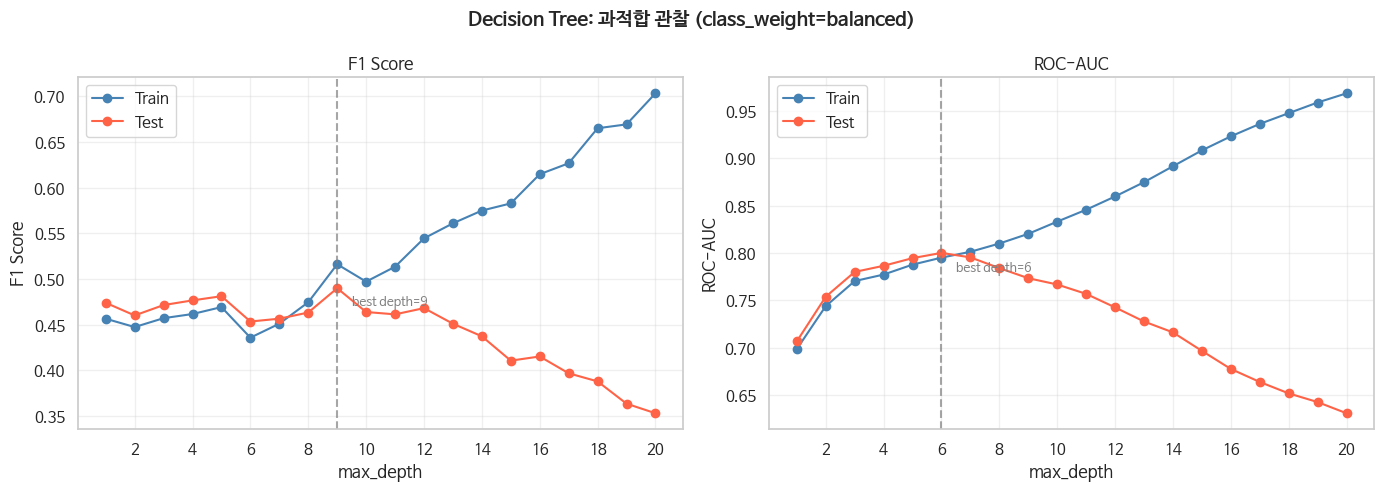

In [56]:
# 시각화

import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Tree: 과적합 관찰 (class_weight=balanced)', fontsize=14, fontweight='bold')

for ax, train_s, test_s, metric in zip(
    axes,
    [train_f1, train_auc],
    [test_f1,  test_auc],
    ['F1 Score', 'ROC-AUC']
):
    ax.plot(depths, train_s, 'o-', label='Train', color='steelblue')
    ax.plot(depths, test_s,  'o-', label='Test',  color='tomato')

    # 최적 depth 표시
    best_d = np.argmax(test_s) + 1
    ax.axvline(x=best_d, linestyle='--', color='gray', alpha=0.7)
    ax.annotate(f'best depth={best_d}', xy=(best_d, max(test_s)),
                xytext=(best_d+0.5, max(test_s)-0.02), fontsize=9, color='gray')

    ax.set_title(metric)
    ax.set_xlabel('max_depth')
    ax.set_ylabel(metric)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


- 현재 F1은 0.49 -> 아직 낮음. 0.7 이상으로 끌어올려야 함
- AUC는 0.8 -> 이미 판별력 확보
- 지금 단계의 best_depth : F 0.6 기준으로 진행

In [57]:
# 라이브러리 부르기
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, f1_score
)

In [58]:
# 모델 설정
best_depth_auc = results["AUC"][0] + 1
final_depth = best_depth_auc

model = DecisionTreeClassifier(
    max_depth=final_depth,
    class_weight='balanced',
    random_state=42
)

# 학습 및 예측
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 확률 값 추출 (0: no, 1: yes)
y_proba = model.predict_proba(X_test)[:, 1]

# 결과 출력
report_title = f"Final Model Report (depth={final_depth})"

print(f"{report_title:^50}") # 제목 중앙 정렬
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
auc_val = roc_auc_score(y_test, y_proba)
print(f"  ROC-AUC Score : {auc_val:.4f}")

           Final Model Report (depth=6)           
              precision    recall  f1-score   support

          no       0.95      0.83      0.89      7307
         yes       0.34      0.69      0.45       928

    accuracy                           0.81      8235
   macro avg       0.65      0.76      0.67      8235
weighted avg       0.88      0.81      0.84      8235

  ROC-AUC Score : 0.8002


# 모델링 2단계

## RF 모델

In [59]:
# 라이브러리 부르기
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [60]:
# 기본 RF 모델
rf = RandomForestClassifier(
    n_estimators=100,       # 트리 100개
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # 전체 CPU 사용
)
rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


print(f"{'Random Forest Report (n=100)':^50}")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
print(f"  ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")


           Random Forest Report (n=100)           
              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7307
         yes       0.55      0.28      0.37       928

    accuracy                           0.89      8235
   macro avg       0.73      0.63      0.66      8235
weighted avg       0.87      0.89      0.88      8235

  ROC-AUC Score : 0.7780


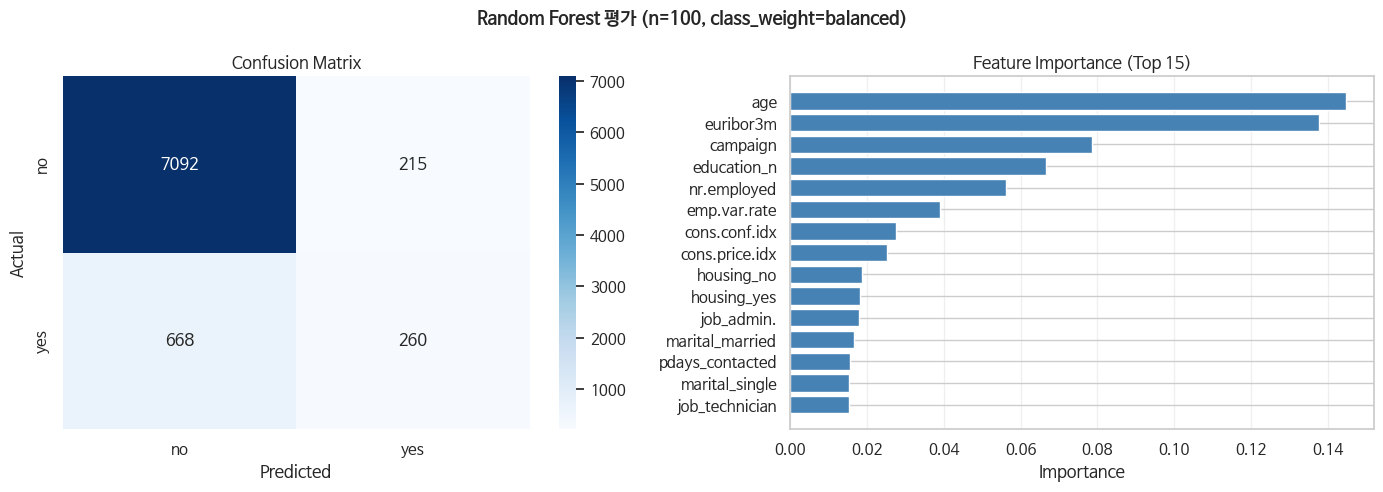

In [61]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest 평가 (n=100, class_weight=balanced)',
             fontsize=13, fontweight='bold')

# 혼동행렬
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['no', 'yes'],
    yticklabels=['no', 'yes'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 속성 중요도 (상위 15개)
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1][:15]
feat_names  = X_train.columns[indices]

axes[1].barh(range(15), importances[indices][::-1], color='steelblue')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feat_names[::-1])
axes[1].set_title('Feature Importance (Top 15)')
axes[1].set_xlabel('Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## GridSearchCV 튜닝

In [62]:
# 셋업 및 파라미터 그리드 정의
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, make_scorer, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 탐색할 파라미터 그리드 (총 72가지 조합)
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [6, 8, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}

# 기본 모델 설정
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# GridSearchCV 객체 생성 (Yes F1 최적화, 5-Fold)
grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    scoring    = make_scorer(f1_score),
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

In [63]:
# 하이퍼파라미터 튜닝
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [6, 8, 10, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring=make_scorer(f1_score, response_method='predict'),
             verbose=1)

In [64]:
# 최적 파라미터
print(f"{'Best Parameters':^50}")

for k, v in grid_search.best_params_.items():
    print(f"  {k:<20} : {v}")
print(f"\n  CV Best F1 Score : {grid_search.best_score_:.4f}")


# 최적 모델(best_estimator)로 Test 세트 평가
best_rf = grid_search.best_estimator_
y_pred  = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]


print(f"{'Random Forest Report (Tuned)':^50}")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

auc_score = roc_auc_score(y_test, y_proba)
print(f"  ROC-AUC Score : {auc_score:.4f}")


                 Best Parameters                  
  max_depth            : None
  max_features         : sqrt
  min_samples_leaf     : 5
  n_estimators         : 100

  CV Best F1 Score : 0.4977
           Random Forest Report (Tuned)           
              precision    recall  f1-score   support

          no       0.95      0.91      0.93      7307
         yes       0.45      0.61      0.52       928

    accuracy                           0.87      8235
   macro avg       0.70      0.76      0.72      8235
weighted avg       0.89      0.87      0.88      8235

  ROC-AUC Score : 0.8047


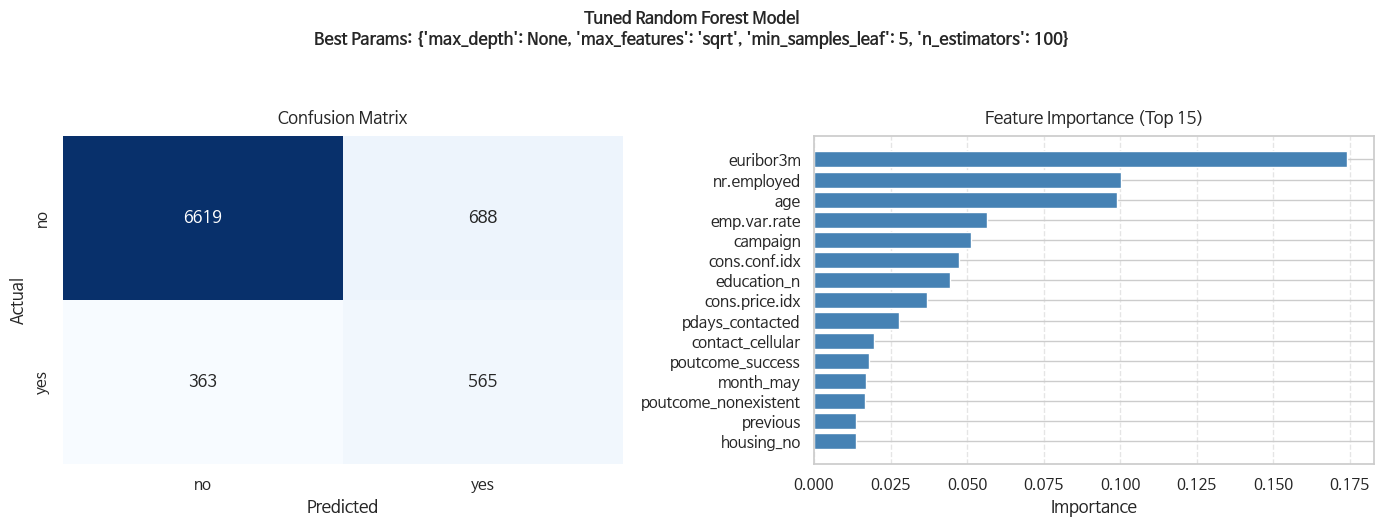

In [65]:
# 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Tuned Random Forest Model\nBest Params: {grid_search.best_params_}',
             fontsize=12, fontweight='bold', y=1.05)

# 혼동 행렬 (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['no', 'yes'],
    yticklabels=['no', 'yes'],
    ax=axes[0], cbar=False
)
axes[0].set_title('Confusion Matrix', pad=10)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 속성 중요도 (Feature Importance - 상위 15개)
importances = best_rf.feature_importances_
indices     = np.argsort(importances)[-15:] # 오름차순 정렬 후 상위 15개만 추출 (코드가 더 깔끔해짐)
feat_names  = X_train.columns[indices]

axes[1].barh(range(15), importances[indices], color='steelblue')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feat_names)
axes[1].set_title('Feature Importance (Top 15)', pad=10)
axes[1].set_xlabel('Importance')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 최적 파라미터를 적용한 RF 모델
final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced', # 잊지 말고 꼭 챙겨야 할 데이터 불균형 옵션!
    random_state=42,
    n_jobs=-1
)

# 전체 Train 데이터로 단일 학습
final_rf.fit(X_train, y_train)

# 예측 및 최종 평가
y_pred_final  = final_rf.predict(X_test)
y_proba_final = final_rf.predict_proba(X_test)[:, 1]


print(f"{'Final Production Model Report':^50}")
print(classification_report(y_test, y_pred_final, target_names=['no', 'yes']))
print(f"  ROC-AUC Score : {roc_auc_score(y_test, y_proba_final):.4f}")


          Final Production Model Report           
              precision    recall  f1-score   support

          no       0.95      0.91      0.93      7307
         yes       0.45      0.61      0.52       928

    accuracy                           0.87      8235
   macro avg       0.70      0.76      0.72      8235
weighted avg       0.89      0.87      0.88      8235

  ROC-AUC Score : 0.8047


# 모델링 3단계

## 부스팅

In [67]:
# XGBoost
from xgboost import XGBClassifier

# 불균형 비율 계산 (scale_pos_weight)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

print(f"  neg : {neg}, pos : {pos}")
print(f"  scale_pos_weight : {spw:.2f}")

  neg : 29227, pos : 3711
  scale_pos_weight : 7.88


In [68]:
# 학습 훈련
xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    scale_pos_weight  = spw,      # 불균형 처리 핵심
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    eval_metric       = 'logloss',
    n_jobs            = -1
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [69]:
# 평가
y_pred  = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]


print(f"{'XGBoost Report':^50}")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
print(f"  ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")


                  XGBoost Report                  
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      7307
         yes       0.39      0.64      0.49       928

    accuracy                           0.85      8235
   macro avg       0.67      0.76      0.70      8235
weighted avg       0.89      0.85      0.86      8235

  ROC-AUC Score : 0.8057


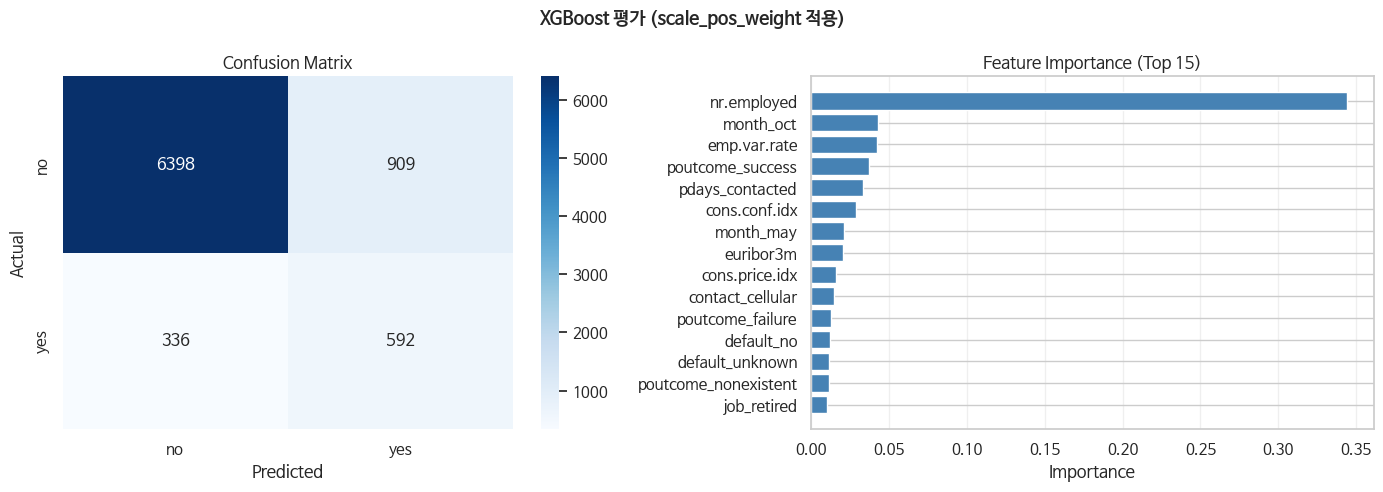

In [70]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost 평가 (scale_pos_weight 적용)',
             fontsize=13, fontweight='bold')

# 혼동행렬
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['no', 'yes'],
    yticklabels=['no', 'yes'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 속성 중요도 (상위 15개)
importances = xgb.feature_importances_
indices     = np.argsort(importances)[::-1][:15]
feat_names  = X_train.columns[indices]

axes[1].barh(range(15), importances[indices][::-1], color='steelblue')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feat_names[::-1])
axes[1].set_title('Feature Importance (Top 15)')
axes[1].set_xlabel('Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## XG Boost GridSearch

In [71]:
# 탐색 파라미터 그리드
param_grid = {
    'n_estimators'  : [200, 300],
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

print(f"총 조합 수 : {2*3*3*2*2}가지")
print(f"CV 5-Fold  : {2*3*3*2*2*5}번 학습 예정")

총 조합 수 : 72가지
CV 5-Fold  : 360번 학습 예정


In [72]:
# 학습 훈련
xgb_base = XGBClassifier(
    scale_pos_weight = spw,
    random_state     = 42,
    eval_metric      = 'logloss',
    n_jobs           = -1
)

grid_search_xgb = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = make_scorer(f1_score),
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [4, 6, 8], 'n_estimators': [200, 300],
                         'subsample': [0.7, 0.9]},
             scoring=make_scorer(f1_score, response_method='predict'),
             verbose=1)

In [73]:
# 최적 파라미터 출력
print(f"{'Best Parameters':^50}")

for k, v in grid_search_xgb.best_params_.items():
    print(f"  {k:<20} : {v}")
print(f"\n  CV Best F1 Score : {grid_search_xgb.best_score_:.4f}")

                 Best Parameters                  
  colsample_bytree     : 0.9
  learning_rate        : 0.01
  max_depth            : 8
  n_estimators         : 200
  subsample            : 0.7

  CV Best F1 Score : 0.4829


In [74]:
# 평가

best_xgb = grid_search_xgb.best_estimator_
y_pred   = best_xgb.predict(X_test)
y_proba  = best_xgb.predict_proba(X_test)[:, 1]


print(f"{'XGBoost Report (Tuned)':^50}")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
print(f"  ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

              XGBoost Report (Tuned)              
              precision    recall  f1-score   support

          no       0.95      0.89      0.92      7307
         yes       0.42      0.63      0.51       928

    accuracy                           0.86      8235
   macro avg       0.69      0.76      0.71      8235
weighted avg       0.89      0.86      0.87      8235

  ROC-AUC Score : 0.8161


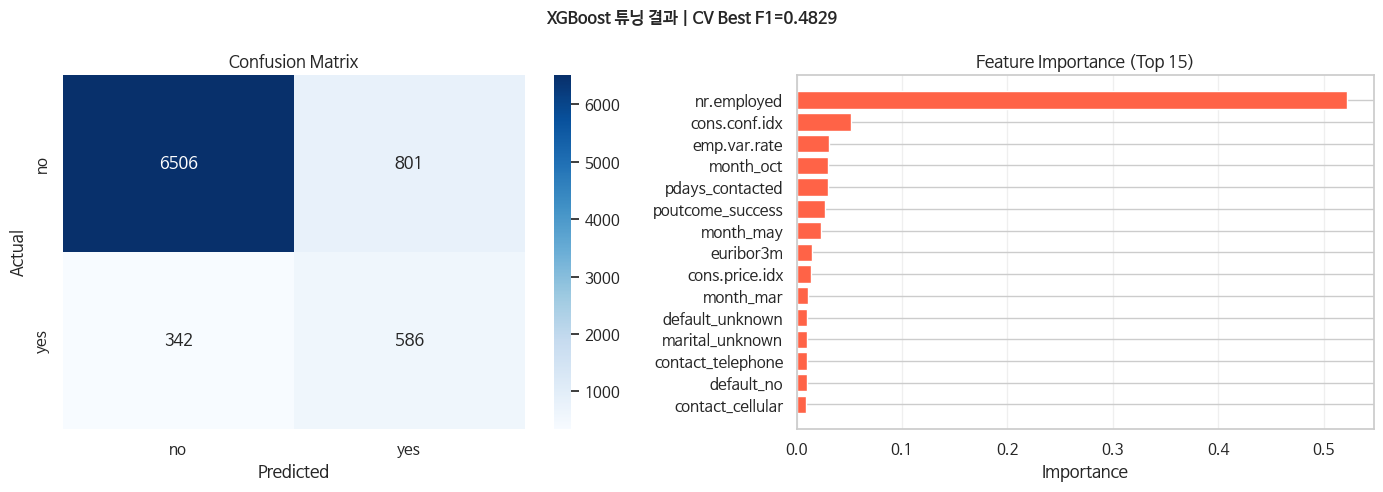

In [75]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'XGBoost 튜닝 결과 | CV Best F1={grid_search_xgb.best_score_:.4f}',
             fontsize=12, fontweight='bold')

# 혼동행렬
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['no', 'yes'],
    yticklabels=['no', 'yes'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 속성 중요도 (상위 15개)
importances = best_xgb.feature_importances_
indices     = np.argsort(importances)[::-1][:15]
feat_names  = X_train.columns[indices]

axes[1].barh(range(15), importances[indices][::-1], color='tomato')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feat_names[::-1])
axes[1].set_title('Feature Importance (Top 15)')
axes[1].set_xlabel('Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

- XGB 튜닝 결과:

    yes F1   0.49 → 0.51  소폭 개선

    ROC-AUC  0.81 → 0.8161  3모델 중 최고 ✅

- RF 튜닝 vs XGB 튜닝:

    yes F1    RF 0.52 > XGB 0.51  → RF 근소 우세

    ROC-AUC   RF 0.80 < XGB 0.82  → XGB 우세

    yes Recall RF 0.61 > XGB 0.63  → 거의 동일

## RF vs. XGBoost 임계값 조정 실험

In [76]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 실험할 임계값 범위
thresholds = [0.5, 0.4, 0.3, 0.2]

# 비교할 모델 2개
models = {
    'RF (튜닝)' : (best_rf,  best_rf.predict_proba(X_test)[:, 1]),
    'XGB (튜닝)': (best_xgb, best_xgb.predict_proba(X_test)[:, 1])
}

print(f"  임계값 : {thresholds}")
print(f"  모델   : {list(models.keys())}")

  임계값 : [0.5, 0.4, 0.3, 0.2]
  모델   : ['RF (튜닝)', 'XGB (튜닝)']


In [77]:
# 임계값별 지표 계산
from sklearn.metrics import f1_score, precision_score, recall_score

results = {}  # 결과 저장

for model_name, (model, proba) in models.items():
    results[model_name] = []
    for t in thresholds:
        y_pred_t = (proba >= t).astype(int)
        results[model_name].append({
            'threshold' : t,
            'precision' : precision_score(y_test, y_pred_t),
            'recall'    : recall_score(y_test, y_pred_t),
            'f1'        : f1_score(y_test, y_pred_t),
            'auc'       : roc_auc_score(y_test, proba)
        })


In [78]:
# 수치 출력
for model_name, result_list in results.items():
    print("=" * 55)
    print(f"  {model_name}")
    print("=" * 55)
    print(f"  {'threshold':^10} {'precision':^10} {'recall':^10} {'f1':^10}")
    print("-" * 55)
    for r in result_list:
        print(f"  {r['threshold']:^10.1f} "
              f"{r['precision']:^10.4f} "
              f"{r['recall']:^10.4f} "
              f"{r['f1']:^10.4f}")
    print()

  RF (튜닝)
  threshold  precision    recall       f1    
-------------------------------------------------------
     0.5       0.4509     0.6088     0.5181  
     0.4       0.3893     0.6498     0.4869  
     0.3       0.2811     0.7263     0.4053  
     0.2       0.1822     0.8211     0.2982  

  XGB (튜닝)
  threshold  precision    recall       f1    
-------------------------------------------------------
     0.5       0.4225     0.6315     0.5063  
     0.4       0.3153     0.7101     0.4367  
     0.3       0.1572     0.8966     0.2676  
     0.2       0.1187     0.9849     0.2118  



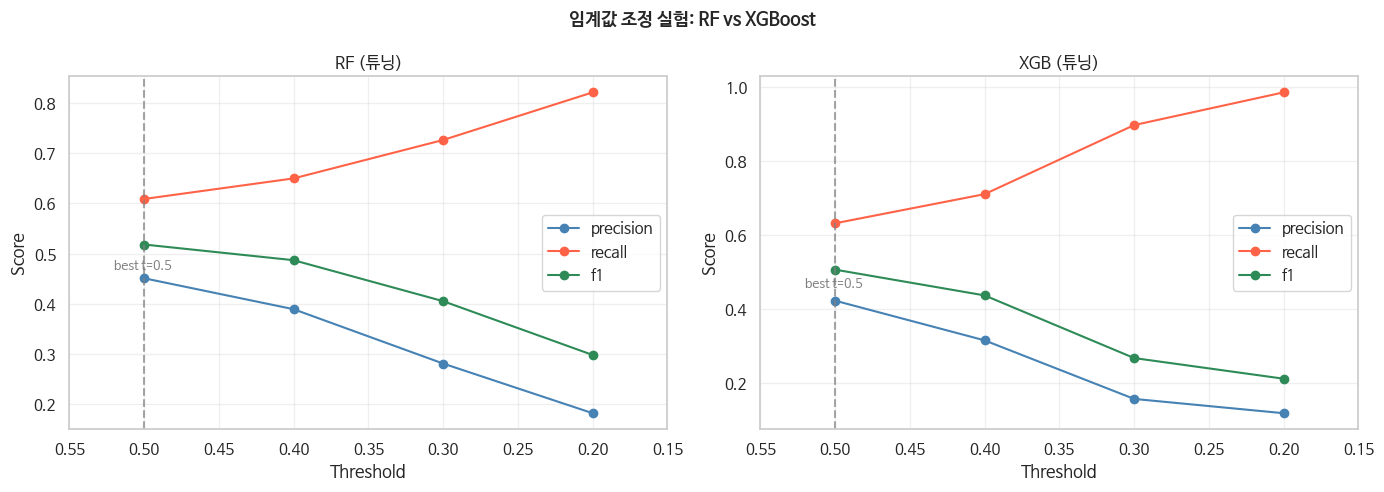

In [79]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('임계값 조정 실험: RF vs XGBoost',
             fontsize=13, fontweight='bold')

colors = {
    'precision': 'steelblue',
    'recall'   : 'tomato',
    'f1'       : 'seagreen'
}

for ax, (model_name, result_list) in zip(axes, results.items()):
    x = [r['threshold'] for r in result_list]
    for metric, color in colors.items():
        y = [r[metric] for r in result_list]
        ax.plot(x, y, 'o-', label=metric, color=color)

    # F1 최고점 표시
    best_t = max(result_list, key=lambda r: r['f1'])
    ax.axvline(x=best_t['threshold'], linestyle='--',
               color='gray', alpha=0.7)
    ax.annotate(f"best t={best_t['threshold']}",
                xy=(best_t['threshold'], best_t['f1']),
                xytext=(best_t['threshold']+0.02, best_t['f1']-0.05),
                fontsize=9, color='gray')

    ax.set_title(model_name)
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_xlim(0.15, 0.55)
    ax.invert_xaxis()   # 왼쪽으로 갈수록 임계값 낮아짐
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

① RF는 임계값 조정에 둔감
0.5 → 0.3: Recall +0.12, F1 -0.11

    → 낮춰도 극적인 변화 없음
    → 이미 0.5에서 균형점 찾은 상태

② XGB는 임계값 조정에 민감
0.5 → 0.3: Recall +0.27, F1 -0.24

    → 임계값 낮출수록 Recall 폭발적 상승
    → 대신 Precision 급락 (오탐 폭증)

# 최종 모델 확정 후 duration 포함 비교 실험

In [80]:
# duration 포함 버전 모델 정의
from xgboost import XGBClassifier

xgb_full = XGBClassifier(
    **grid_search_xgb.best_params_,  # 기존 최적 파라미터 그대로 언패킹
    scale_pos_weight = spw,           # 불균형 처리 (동일하게 유지)
    random_state     = 42,
    eval_metric      = 'logloss',
    n_jobs           = -1
)

print("best_params_:", grid_search_xgb.best_params_)

best_params_: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.7}


In [81]:
# 학습
xgb_full.fit(X_train_full, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [82]:
# Main vs Full 성능 비교
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# Main 버전 예측
y_pred_main  = best_xgb.predict(X_test)
y_proba_main = best_xgb.predict_proba(X_test)[:, 1]

# Full 버전 예측
y_pred_full  = xgb_full.predict(X_test_full)
y_proba_full = xgb_full.predict_proba(X_test_full)[:, 1]

print("=" * 55)
print(f"{'[Main] XGBoost — duration 제외':^55}")
print("=" * 55)
print(classification_report(y_test, y_pred_main, target_names=['no', 'yes']))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba_main):.4f}")
print(f"  F1(yes) : {f1_score(y_test, y_pred_main):.4f}")

print()
print("=" * 55)
print(f"{'[Full] XGBoost — duration 포함':^55}")
print("=" * 55)
print(classification_report(y_test, y_pred_full, target_names=['no', 'yes']))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba_full):.4f}")
print(f"  F1(yes) : {f1_score(y_test, y_pred_full):.4f}")

             [Main] XGBoost — duration 제외              
              precision    recall  f1-score   support

          no       0.95      0.89      0.92      7307
         yes       0.42      0.63      0.51       928

    accuracy                           0.86      8235
   macro avg       0.69      0.76      0.71      8235
weighted avg       0.89      0.86      0.87      8235

  ROC-AUC : 0.8161
  F1(yes) : 0.5063

             [Full] XGBoost — duration 포함              
              precision    recall  f1-score   support

          no       0.99      0.87      0.92      7307
         yes       0.47      0.92      0.62       928

    accuracy                           0.87      8235
   macro avg       0.73      0.90      0.77      8235
weighted avg       0.93      0.87      0.89      8235

  ROC-AUC : 0.9514
  F1(yes) : 0.6235


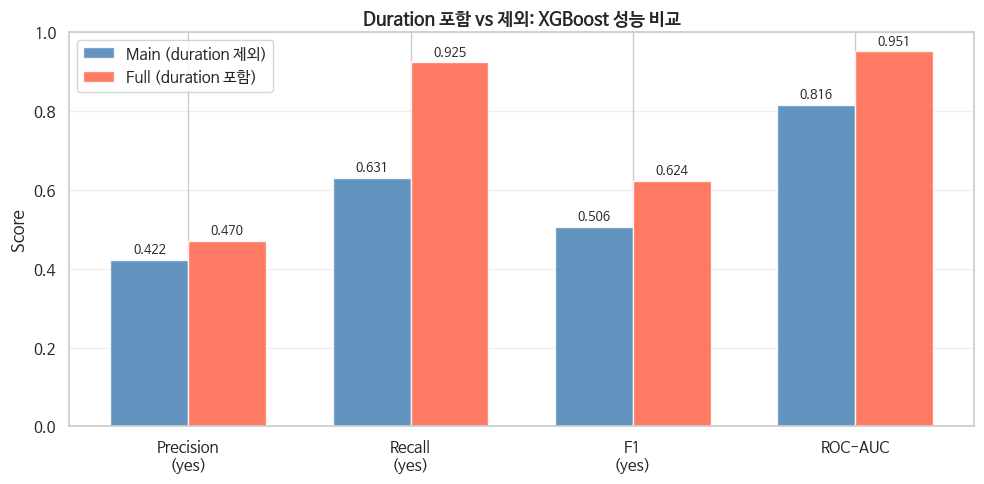


📊 성능 차이 (Full - Main)
--------------------------------------
  Precision(yes)   : 0.4225 → 0.4704  ▲ 0.0479
  Recall(yes)      : 0.6315 → 0.9246  ▲ 0.2931
  F1(yes)          : 0.5063 → 0.6235  ▲ 0.1173
  ROC-AUC          : 0.8161 → 0.9514  ▲ 0.1353


In [83]:
# 시각화
from sklearn.metrics import precision_score, recall_score

labels      = ['Precision\n(yes)', 'Recall\n(yes)', 'F1\n(yes)', 'ROC-AUC']
main_scores = [
    precision_score(y_test, y_pred_main),
    recall_score(y_test,    y_pred_main),
    f1_score(y_test,        y_pred_main),
    roc_auc_score(y_test,   y_proba_main)
]
full_scores = [
    precision_score(y_test, y_pred_full),
    recall_score(y_test,    y_pred_full),
    f1_score(y_test,        y_pred_full),
    roc_auc_score(y_test,   y_proba_full)
]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, main_scores, width, label='Main (duration 제외)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, full_scores, width, label='Full (duration 포함)',  color='tomato',    alpha=0.85)

for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_title('Duration 포함 vs 제외: XGBoost 성능 비교', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 성능 차이 요약
print("\n📊 성능 차이 (Full - Main)")
print("-" * 38)
for label, m, f in zip(['Precision(yes)', 'Recall(yes)', 'F1(yes)', 'ROC-AUC'], main_scores, full_scores):
    diff  = f - m
    arrow = "▲" if diff > 0 else "▼"
    print(f"  {label:<16} : {m:.4f} → {f:.4f}  {arrow} {abs(diff):.4f}")

# 모델 평가 & 시각화

## ROC & PR 곡선

In [84]:
# ROC & PR 곡선 라이브러리
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# 최종 모델 확률값
y_proba_main = best_xgb.predict_proba(X_test)[:, 1]

print(f"  샘플 수  : {len(y_test)}")
print(f"  yes 비율 : {y_test.mean():.3f}")

  샘플 수  : 8235
  yes 비율 : 0.113


In [85]:
# ROC / PR 수치 계산

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_main)
roc_auc = auc(fpr, tpr)

# PR
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba_main)
avg_precision = average_precision_score(y_test, y_proba_main)

print(f"  ROC-AUC        : {roc_auc:.4f}")
print(f"  Avg Precision  : {avg_precision:.4f}")

  ROC-AUC        : 0.8161
  Avg Precision  : 0.4846


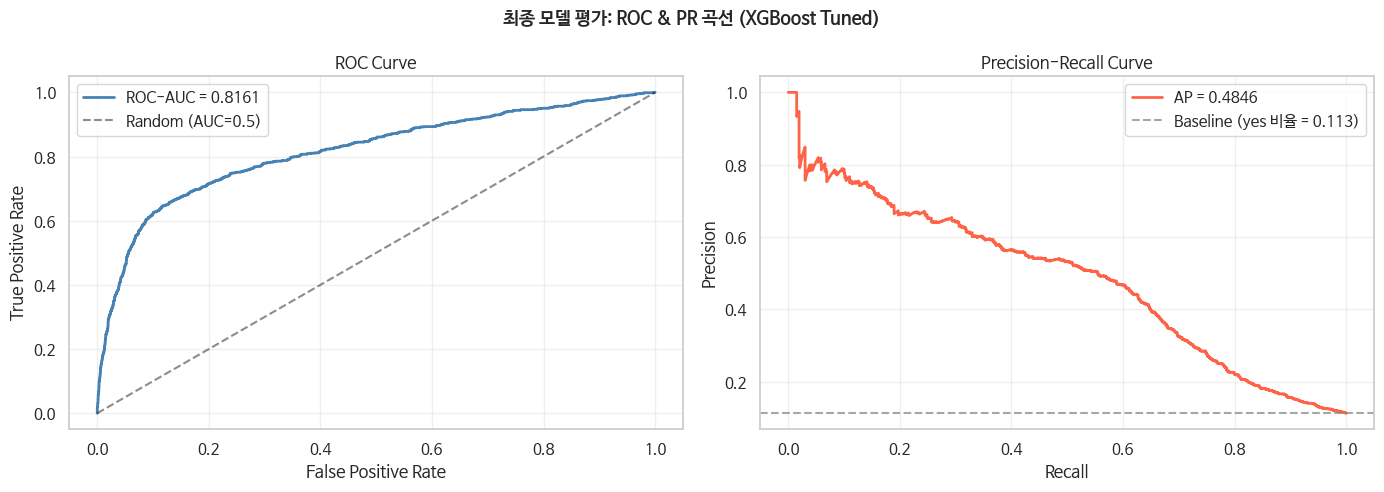

In [86]:
# ROC 곡선 & PR 곡선
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('최종 모델 평가: ROC & PR 곡선 (XGBoost Tuned)', fontsize=13, fontweight='bold')

# ── ROC 곡선
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── PR 곡선
baseline = y_test.mean()   # 랜덤 모델의 Precision 기준선
axes[1].plot(recall_curve, precision_curve, color='tomato', linewidth=2, label=f'AP = {avg_precision:.4f}')
axes[1].axhline(y=baseline, linestyle='--', color='gray', alpha=0.7, label=f'Baseline (yes 비율 = {baseline:.3f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Importance Top15

In [87]:
# 최종 모델: best_xgb
# feature 이름과 중요도 추출
importances = best_xgb.feature_importances_
feat_names  = X_train.columns

# 상위 15개 인덱스 (내림차순)
indices = np.argsort(importances)[::-1][:15]

print("Top 15 Feature Importance")
print("-" * 35)
for rank, idx in enumerate(indices, 1):
    print(f"  {rank:>2}. {feat_names[idx]:<25} {importances[idx]:.4f}")

Top 15 Feature Importance
-----------------------------------
   1. nr.employed               0.5215
   2. cons.conf.idx             0.0514
   3. emp.var.rate              0.0309
   4. month_oct                 0.0302
   5. pdays_contacted           0.0295
   6. poutcome_success          0.0266
   7. month_may                 0.0233
   8. euribor3m                 0.0147
   9. cons.price.idx            0.0134
  10. month_mar                 0.0110
  11. default_unknown           0.0103
  12. marital_unknown           0.0101
  13. contact_telephone         0.0098
  14. default_no                0.0096
  15. contact_cellular          0.0091


In [88]:
# 가설 검증 체크
# poutcome, euribor3m, duration, nr.employed 순위 확인

target_vars = ['poutcome_success', 'euribor3m', 'duration', 'nr.employed']

print("가설 변수 순위 확인")
print("-" * 40)

all_ranked = np.argsort(importances)[::-1]
for var in target_vars:
    # 컬럼명 부분 매칭 (OHE로 변형된 이름 대응)
    matched = [(i, feat_names[i]) for i in range(len(feat_names)) if var in feat_names[i]]
    for idx, name in matched:
        rank = np.where(all_ranked == idx)[0][0] + 1
        print(f"  {name:<30} → {rank:>2}위  (importance: {importances[idx]:.4f})")

가설 변수 순위 확인
----------------------------------------
  poutcome_success               →  6위  (importance: 0.0266)
  euribor3m                      →  8위  (importance: 0.0147)
  nr.employed                    →  1위  (importance: 0.5215)


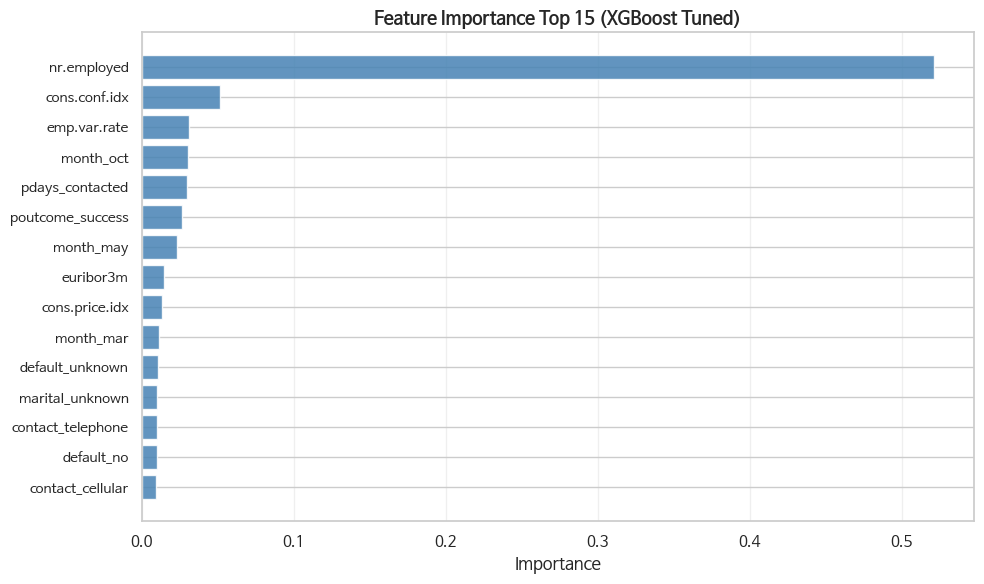

In [89]:
# 시각화
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    range(15),
    importances[indices][::-1],
    color='steelblue',
    alpha=0.85
)
ax.set_yticks(range(15))
ax.set_yticklabels(feat_names[indices][::-1], fontsize=10)
ax.set_title('Feature Importance Top 15 (XGBoost Tuned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
# 부록. October Anomaly — 10월 이상 현상 심층 분석

> Feature Importance 상위권에 `month_oct`(10월)이 진입한 이유 찾기


In [90]:
# 데이터에 연도 컬럼이 없으므로, Euribor3m 범위로 연도를 역추정한다
# 2008년: Euribor3m > 4.0%  (리먼 사태 직후 고금리 구간)
# 2009년: Euribor3m < 0.85% (ECB 기준금리 사상 최저)
# 2010년: 그 외 구간

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

oct_df = bank.copy()

def infer_year(euribor):
    if euribor > 4.0:
        return 2008
    elif euribor < 0.85:
        return 2009
    else:
        return 2010

oct_df['est_year'] = oct_df['euribor3m'].apply(infer_year)
oct_df['sub'] = oct_df['target_n']

print('Setup 완료')
print(oct_df['est_year'].value_counts().sort_index())
overall_rate = oct_df['sub'].mean() * 100
print(f'\n전체 평균 가입률: {overall_rate:.1f}%')


Setup 완료
est_year
2008    27665
2009     2441
2010    11067
Name: count, dtype: int64

전체 평균 가입률: 11.3%


구분                가입률       건수       전체대비
----------------------------------------------------
전체 평균           11.3%   41,173         --
2008년 10월       62.7%       67       5.6x
2009년 10월       40.4%      446       3.6x
2010년 10월       45.6%      204       4.0x


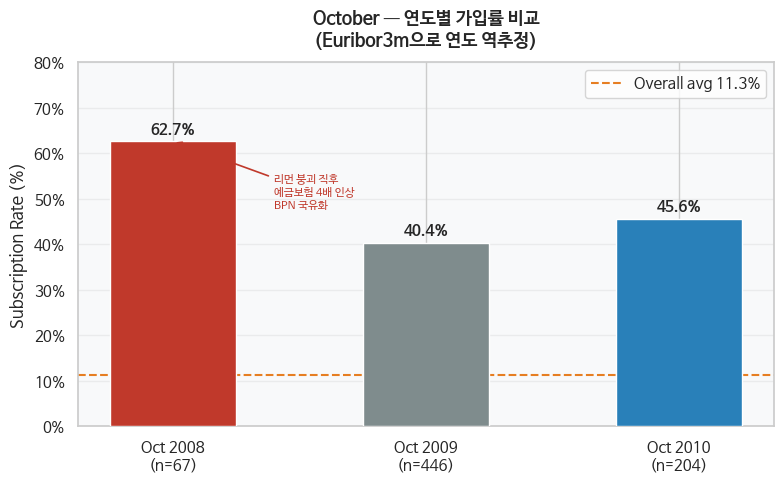

In [91]:
# 연도별 10월 가입률 비교

oct_only = oct_df[oct_df['month_oct'] == 1]
oct_by_year = oct_only.groupby('est_year')['sub'].agg(['mean', 'count']).reset_index()
oct_by_year['rate'] = oct_by_year['mean'] * 100

print('=' * 52)
print(f"{'구분':<12} {'가입률':>8} {'건수':>8} {'전체대비':>10}")
print('-' * 52)
print(f"{'전체 평균':<12} {overall_rate:>7.1f}% {len(oct_df):>8,} {'--':>10}")
for _, row in oct_by_year.iterrows():
    mult = row['rate'] / overall_rate
    label = f"{int(row['est_year'])}년 10월"
    print(f"{label:<12} {row['rate']:>7.1f}% {int(row['count']):>8,} {mult:>9.1f}x")
print('=' * 52)

# 시각화
colors = ['#c0392b', '#7f8c8d', '#2980b9']
labels = [f"Oct {int(y)}\n(n={int(c):,})" for y, c in zip(oct_by_year['est_year'], oct_by_year['count'])]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, oct_by_year['rate'], color=colors, width=0.5, zorder=3)
ax.axhline(overall_rate, color='#e67e22', linestyle='--', linewidth=1.5,
           label=f'Overall avg {overall_rate:.1f}%', zorder=2)

for bar, rate in zip(bars, oct_by_year['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2008년 주석
ax.annotate('리먼 붕괴 직후\n예금보험 4배 인상\nBPN 국유화',
            xy=(0, oct_by_year.iloc[0]['rate']),
            xytext=(0.4, oct_by_year.iloc[0]['rate'] - 15),
            fontsize=8, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))

ax.set_title('October — 연도별 가입률 비교\n(Euribor3m으로 연도 역추정)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Subscription Rate (%)')
ax.set_ylim(0, 80)
ax.legend()
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()


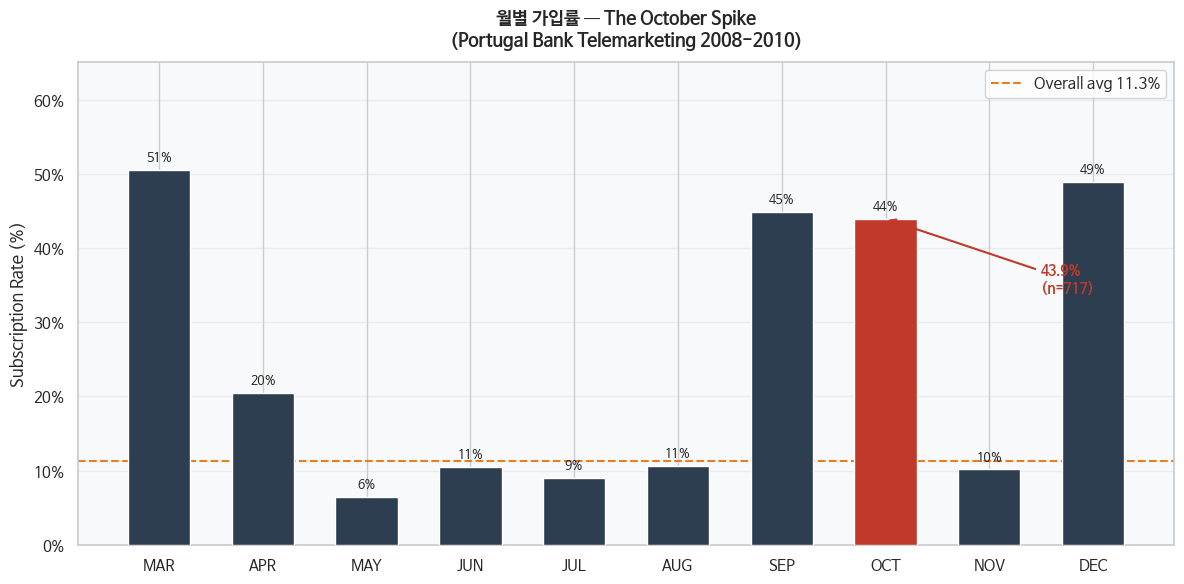

In [92]:
# 10월 스파이크 시각화

month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_data = []

for month_abbr in month_order:
    # Construct the one-hot encoded column name
    month_col_name = f'month_{month_abbr}'

    # Check if the column exists in oct_df
    if month_col_name in oct_df.columns:
        # Filter for rows where this month is active
        month_subset = oct_df[oct_df[month_col_name] == 1]

        # Calculate mean 'sub' and count for this month
        if not month_subset.empty:
            mean_sub = month_subset['sub'].mean()
            count_sub = len(month_subset)
            monthly_data.append({'month': month_abbr, 'mean': mean_sub, 'count': count_sub})

monthly = pd.DataFrame(monthly_data)
monthly['rate'] = monthly['mean'] * 100

# Convert 'month' column to categorical for correct sorting
monthly['month'] = pd.Categorical(monthly['month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month').reset_index(drop=True)

colors_monthly = ['#c0392b' if m == 'oct' else '#2c3e50' for m in monthly['month']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(monthly['month'].str.upper(), monthly['rate'],
              color=colors_monthly, width=0.6, zorder=3)
ax.axhline(overall_rate, color='#e67e22', linestyle='--', linewidth=1.5,
           label=f'Overall avg {overall_rate:.1f}%', zorder=2)

for bar, rate in zip(bars, monthly['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.0f}%', ha='center', va='bottom', fontsize=9)

# 10월 강조 주석
oct_idx  = monthly[monthly['month'] == 'oct'].index[0]
oct_rate = monthly.loc[oct_idx, 'rate']
oct_n    = monthly.loc[oct_idx, 'count']
ax.annotate(f'''{oct_rate:.1f}%
(n={oct_n:,})''',
            xy=(oct_idx, oct_rate),
            xytext=(oct_idx + 1.5, oct_rate - 10),
            fontsize=10, fontweight='bold', color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.set_title('월별 가입률 — The October Spike\n(Portugal Bank Telemarketing 2008-2010)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Subscription Rate (%)')
ax.set_ylim(0, 65)
ax.legend()
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()


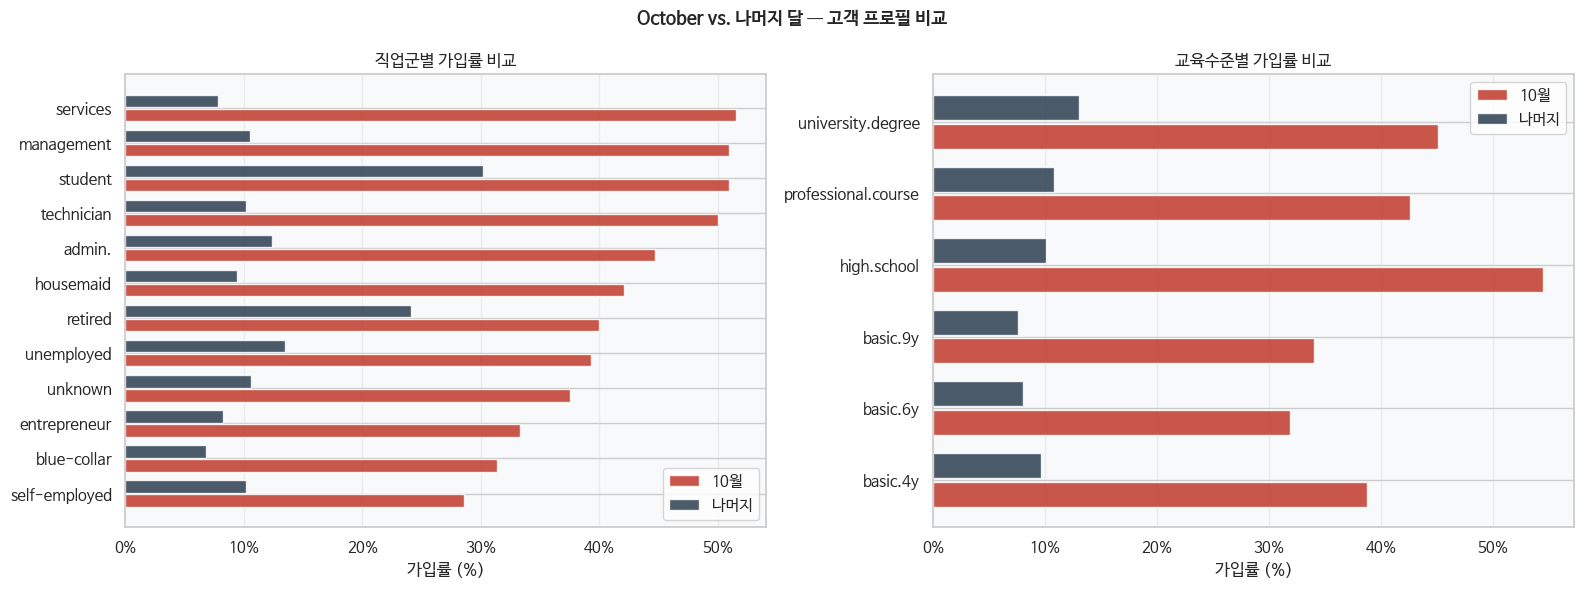


10월 전체 가입률  : 43.9%
나머지 달 가입률  : 10.7%
격차 배율         : 4.1x


In [93]:
# 맥락 검증: 10월 고객 프로필 vs 나머지 달
oct_group   = oct_df[oct_df['month_oct'] == 1]
other_group = oct_df[oct_df['month_oct'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('October vs. 나머지 달 — 고객 프로필 비교', fontsize=13, fontweight='bold')

# ── 직업별 비교 ──────────────────────────────────
ax = axes[0]
job_cols_prefix = [col for col in oct_df.columns if col.startswith('job_')]
job_oct_rates, job_other_rates = {}, {}

for job_col in job_cols_prefix:
    job_category = job_col.replace('job_', '')
    subset_oct   = oct_group[oct_group[job_col] == 1]
    subset_other = other_group[other_group[job_col] == 1]
    if not subset_oct.empty:
        job_oct_rates[job_category]   = subset_oct['sub'].mean() * 100
    if not subset_other.empty:
        job_other_rates[job_category] = subset_other['sub'].mean() * 100

job_df = pd.DataFrame({'10월': pd.Series(job_oct_rates), '나머지': pd.Series(job_other_rates)}).dropna().sort_values('10월', ascending=True)

y_pos = range(len(job_df))
ax.barh([y - 0.2 for y in y_pos], job_df['10월'],   height=0.35, color='#c0392b', label='10월', alpha=0.85)
ax.barh([y + 0.2 for y in y_pos], job_df['나머지'], height=0.35, color='#2c3e50', label='나머지', alpha=0.85)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(job_df.index)
ax.set_title('직업군별 가입률 비교')
ax.set_xlabel('가입률 (%)')
ax.xaxis.set_major_formatter(ticker.PercentFormatter())
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#f8f9fa')

# ── 교육수준별 비교 ───────────────────────────────
ax = axes[1]
education_order = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
    'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': -1
}
rev_education_order = {v: k for k, v in education_order.items()}
edu_display_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                     'high.school', 'professional.course', 'university.degree']

edu_oct_grouped   = oct_group.groupby('education_n')['sub'].mean() * 100
edu_other_grouped = other_group.groupby('education_n')['sub'].mean() * 100

edu_df = pd.DataFrame({
    '10월':  edu_oct_grouped.rename(index=rev_education_order),
    '나머지': edu_other_grouped.rename(index=rev_education_order)
}).reindex(edu_display_order).dropna()

y_pos = range(len(edu_df))
ax.barh([y - 0.2 for y in y_pos], edu_df['10월'],   height=0.35, color='#c0392b', label='10월', alpha=0.85)
ax.barh([y + 0.2 for y in y_pos], edu_df['나머지'], height=0.35, color='#2c3e50', label='나머지', alpha=0.85)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(edu_df.index)
ax.set_title('교육수준별 가입률 비교')
ax.set_xlabel('가입률 (%)')
ax.xaxis.set_major_formatter(ticker.PercentFormatter())
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print(f'\n10월 전체 가입률  : {oct_group["sub"].mean()*100:.1f}%')
print(f'나머지 달 가입률  : {other_group["sub"].mean()*100:.1f}%')
print(f'격차 배율         : {oct_group["sub"].mean()/other_group["sub"].mean():.1f}x')